# Training History Plots

Plots training curves from the JSON histories in `history/` and `history/old/`.

In [4]:
from pathlib import Path
import json
import math
import re

import matplotlib.pyplot as plt
import pandas as pd

try:
    NOTEBOOK_DIR = Path(__file__).resolve().parent
except NameError:
    NOTEBOOK_DIR = Path.cwd()

REPO_ROOT = NOTEBOOK_DIR if (NOTEBOOK_DIR / "history").exists() else NOTEBOOK_DIR.parents[1]
HISTORY_DIR = REPO_ROOT / "history"
PLOTS_DIR = HISTORY_DIR / "plots"
PLOTS_DIR.mkdir(parents=True, exist_ok=True)

history_files = sorted(HISTORY_DIR.glob("*.json")) + sorted((HISTORY_DIR / "old").glob("*.json"))
history_files

[PosixPath('/Users/josh/GWU/protein-sequence-augmentation/history/localization_ae_history.json'),
 PosixPath('/Users/josh/GWU/protein-sequence-augmentation/history/localization_tae_history.json'),
 PosixPath('/Users/josh/GWU/protein-sequence-augmentation/history/solubility_ae_history.json'),
 PosixPath('/Users/josh/GWU/protein-sequence-augmentation/history/solubility_tae_history.json')]

In [5]:
def _as_list(value):
    return value if isinstance(value, list) else []


def _score(history, split, metric):
    return _as_list(history.get(f"{split}_scores", {}).get(metric))


def _epochs(history):
    epochs = _as_list(history.get("epochs"))
    if epochs and isinstance(epochs[0], dict):
        return [row.get("epoch", i + 1) for i, row in enumerate(epochs)]
    if epochs:
        return epochs
    max_len = max(len(_as_list(history.get("train_loss"))), len(_as_list(history.get("val_loss"))), 0)
    return list(range(1, max_len + 1))


def _slug(path):
    name = path.relative_to(HISTORY_DIR).with_suffix("").as_posix().replace("/", "__")
    return re.sub(r"[^A-Za-z0-9._-]+", "_", name).strip("_")


def load_history(path):
    with path.open() as fh:
        history = json.load(fh)
    return {
        "path": path,
        "name": path.relative_to(HISTORY_DIR).as_posix(),
        "epochs": _epochs(history),
        "train_loss": _as_list(history.get("train_loss")),
        "val_loss": _as_list(history.get("val_loss")),
        "train_accuracy": _score(history, "train", "accuracy"),
        "val_accuracy": _score(history, "val", "accuracy"),
        "train_f1": _score(history, "train", "f1"),
        "val_f1": _score(history, "val", "f1"),
    }


runs = [load_history(path) for path in history_files]
pd.DataFrame([
    {
        "run": run["name"],
        "epochs": len(run["epochs"]),
        "final_train_loss": run["train_loss"][-1] if run["train_loss"] else math.nan,
        "final_val_loss": run["val_loss"][-1] if run["val_loss"] else math.nan,
        "best_val_loss": min(run["val_loss"]) if run["val_loss"] else math.nan,
        "final_val_accuracy": run["val_accuracy"][-1] if run["val_accuracy"] else math.nan,
        "best_val_accuracy": max(run["val_accuracy"]) if run["val_accuracy"] else math.nan,
    }
    for run in runs
])

,run,epochs,final_train_loss,final_val_loss,best_val_loss,final_val_accuracy,best_val_accuracy
0,localization_ae_history.json,76,1.703466,2.023589,2.021652,0.347643,0.347695
1,localization_tae_history.json,100,1.728187,2.140048,2.138016,0.312906,0.313002
2,solubility_ae_history.json,40,2.383280,2.341888,1.656901,0.260130,0.441555
3,solubility_tae_history.json,100,1.519150,1.292355,1.292189,0.487078,0.487684


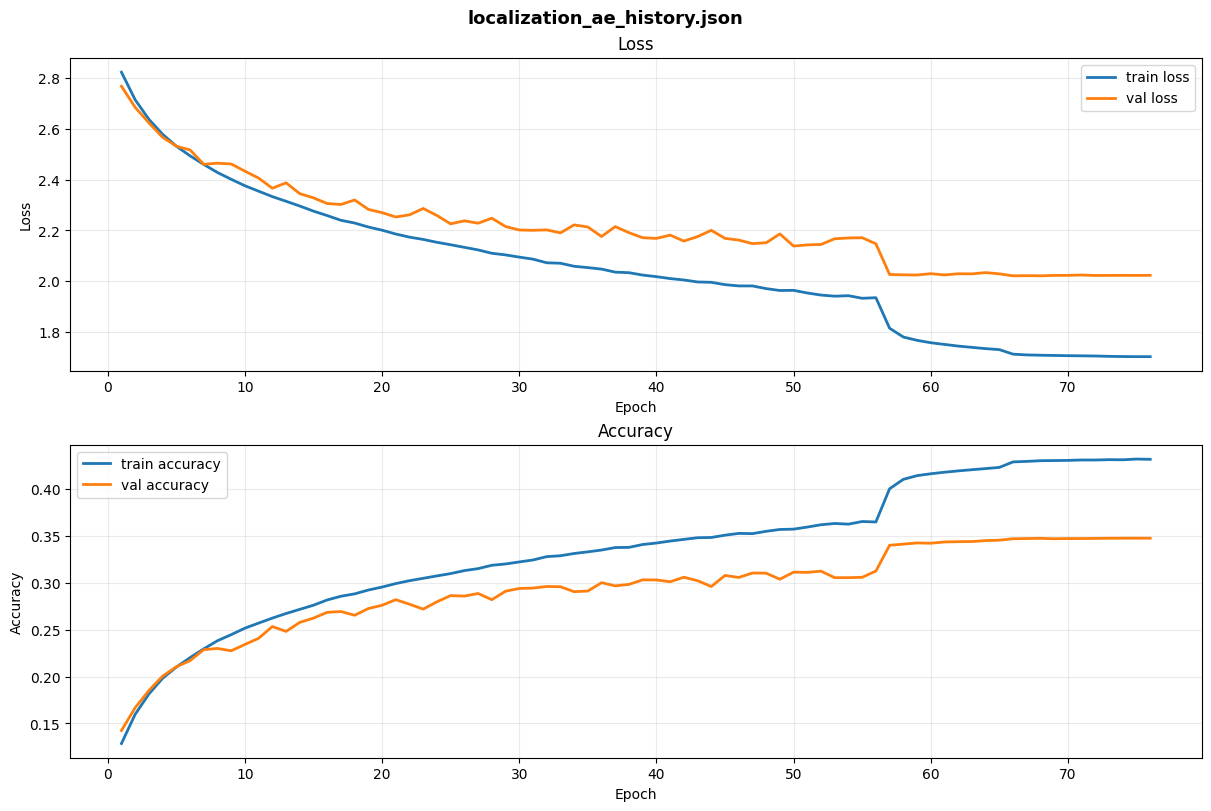

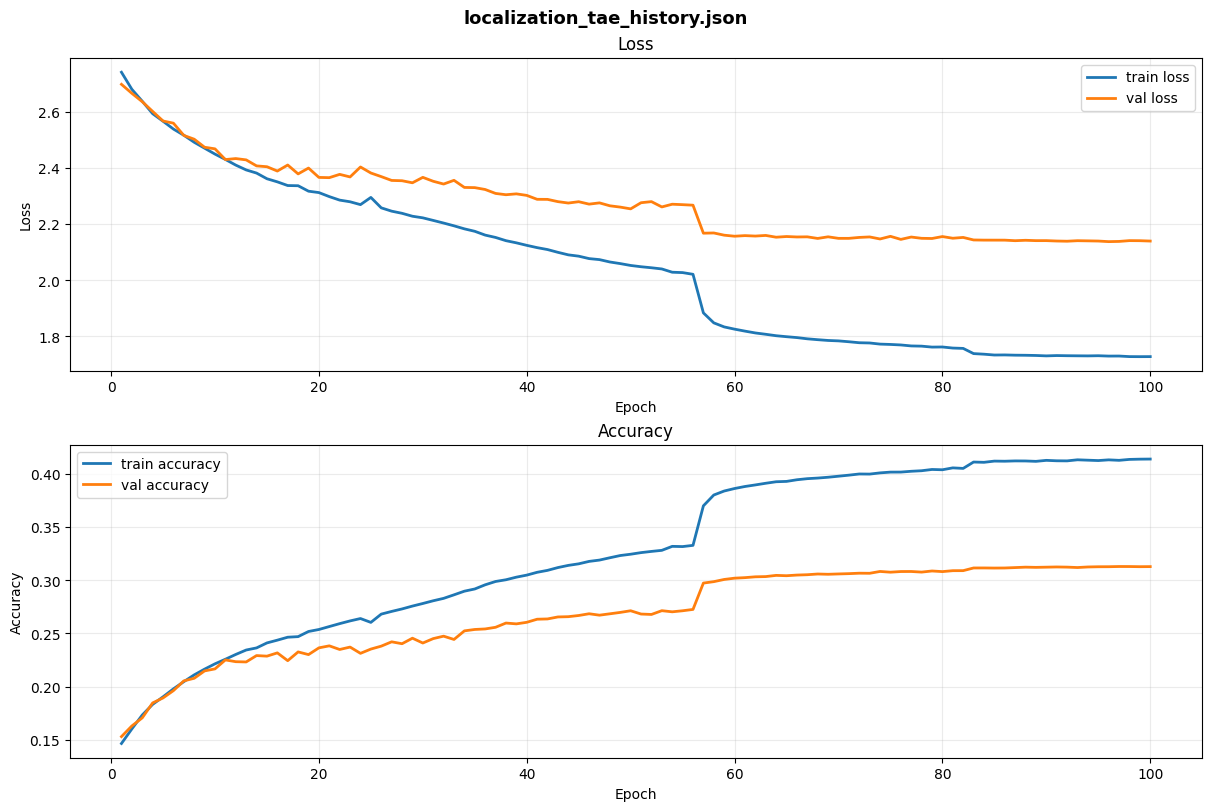

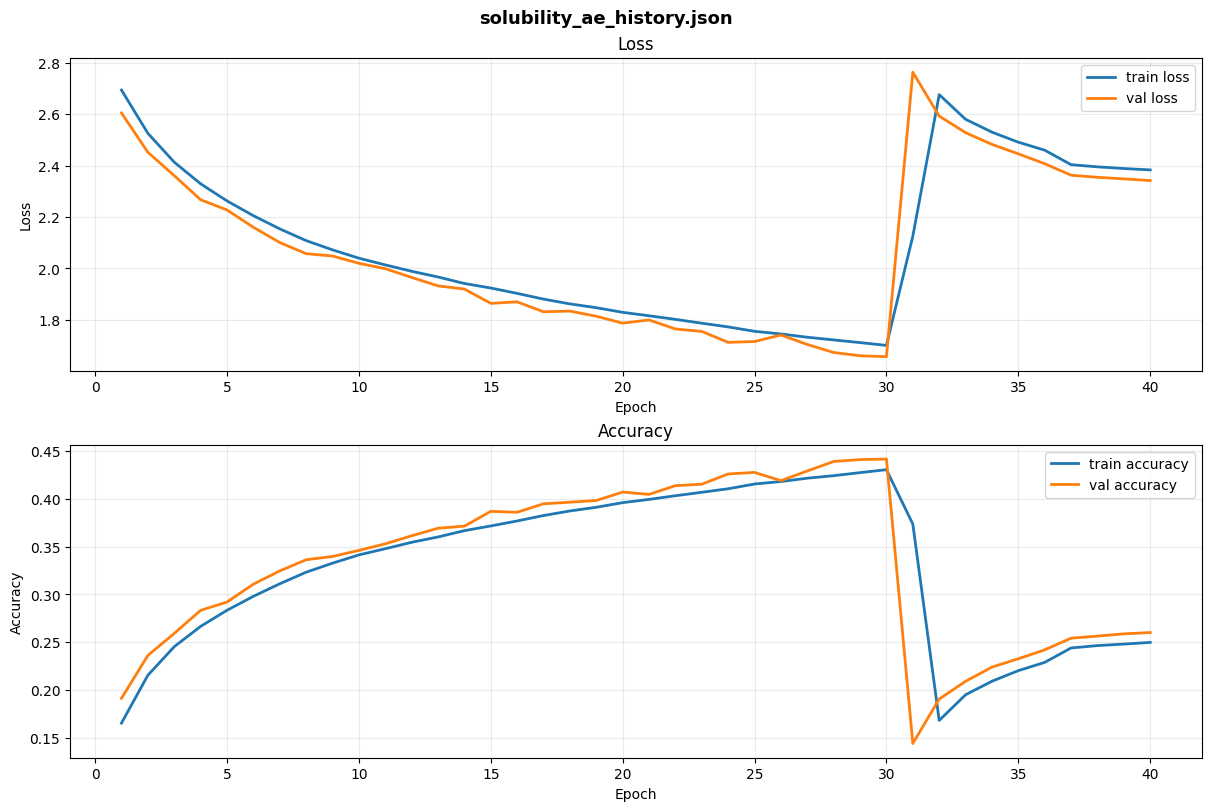

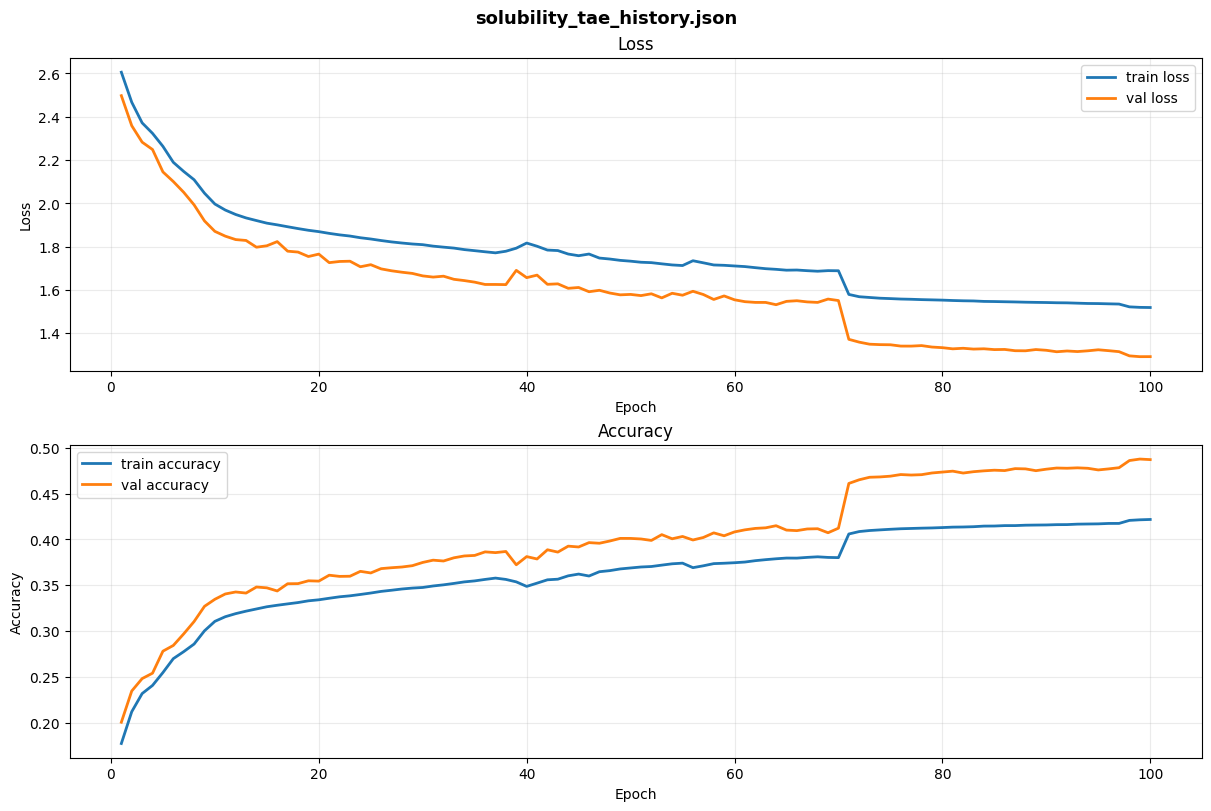

In [11]:
def plot_training_run(run, save=True):
    epochs = run["epochs"]
    fig, axes = plt.subplots(2, figsize=(12, 8), constrained_layout=True)
    fig.suptitle(run["name"], fontsize=13, fontweight="bold")

    ax = axes[0]
    if run["train_loss"]:
        ax.plot(epochs[:len(run["train_loss"])], run["train_loss"], label="train loss", linewidth=2)
    if run["val_loss"]:
        ax.plot(epochs[:len(run["val_loss"])], run["val_loss"], label="val loss", linewidth=2)
    ax.set(title="Loss", xlabel="Epoch", ylabel="Loss")
    ax.grid(True, alpha=0.25)
    ax.legend()

    ax = axes[1]
    if run["train_accuracy"]:
        ax.plot(epochs[:len(run["train_accuracy"])], run["train_accuracy"], label="train accuracy", linewidth=2)
    if run["val_accuracy"]:
        ax.plot(epochs[:len(run["val_accuracy"])], run["val_accuracy"], label="val accuracy", linewidth=2)
    ax.set(title="Accuracy", xlabel="Epoch", ylabel="Accuracy")
    ax.grid(True, alpha=0.25)
    ax.legend()
    
    # ax = axes[2]
    # if run["train_f1"]:
    #     ax.plot(epochs[:len(run["train_f1"])], run["train_f1"], label="train f1", linewidth=2)

    # ax = axes[1, 0]
    # if run["train_f1"]:
    #     ax.plot(epochs[:len(run["train_f1"])], run["train_f1"], label="train f1", linewidth=2)
    # if run["val_f1"]:
    #     ax.plot(epochs[:len(run["val_f1"])], run["val_f1"], label="val f1", linewidth=2)
    # if run["train_f1"] or run["val_f1"]:
    #     ax.legend()
    # else:
    #     ax.text(0.5, 0.5, "No F1 history", ha="center", va="center", transform=ax.transAxes)
    # ax.set(title="F1", xlabel="Epoch", ylabel="F1")
    # ax.grid(True, alpha=0.25)

    # ax = axes[1, 1]
    # if run["train_loss"] and run["val_loss"]:
    #     n = min(len(run["train_loss"]), len(run["val_loss"]), len(epochs))
    #     gap = [run["val_loss"][i] - run["train_loss"][i] for i in range(n)]
    #     ax.axhline(0, color="black", linewidth=1, alpha=0.4)
    #     ax.plot(epochs[:n], gap, label="val loss - train loss", linewidth=2)
    #     ax.legend()
    # else:
    #     ax.text(0.5, 0.5, "No loss gap available", ha="center", va="center", transform=ax.transAxes)
    # ax.set(title="Generalization Gap", xlabel="Epoch", ylabel="Loss Gap")
    # ax.grid(True, alpha=0.25)

    # if save:
    #     fig.savefig(PLOTS_DIR / f"{_slug(run['path'])}.png", dpi=180, bbox_inches="tight")
    # return fig


# Change the index to inspect a different run.
plot_training_run(runs[0])
plot_training_run(runs[1])
plot_training_run(runs[2])
plot_training_run(runs[3])

In [7]:
# def plot_all_runs(runs, save=True):
#     fig, axes = plt.subplots(2, 2, figsize=(14, 9), constrained_layout=True)
#     fig.suptitle("Training History Comparison", fontsize=14, fontweight="bold")

#     panels = [
#         (axes[0, 0], "val_loss", "Validation Loss", "Loss"),
#         (axes[0, 1], "train_loss", "Training Loss", "Loss"),
#         (axes[1, 0], "val_accuracy", "Validation Accuracy", "Accuracy"),
#         (axes[1, 1], "train_accuracy", "Training Accuracy", "Accuracy"),
#     ]
#     for ax, metric, title, ylabel in panels:
#         for run in runs:
#             values = run[metric]
#             if values:
#                 ax.plot(range(1, len(values) + 1), values, label=run["name"], linewidth=1.8)
#         ax.set(title=title, xlabel="Epoch", ylabel=ylabel)
#         ax.grid(True, alpha=0.25)
#         ax.legend(fontsize=7)

#     if save:
#         fig.savefig(PLOTS_DIR / "all_runs_comparison.png", dpi=180, bbox_inches="tight")
#     return fig


# plot_all_runs(runs);

In [8]:
# def plot_validation_summary(runs, save=True):
#     labels = [run["name"] for run in runs]
#     final_val_loss = [run["val_loss"][-1] if run["val_loss"] else math.nan for run in runs]
#     best_val_loss = [min(run["val_loss"]) if run["val_loss"] else math.nan for run in runs]
#     final_val_acc = [run["val_accuracy"][-1] if run["val_accuracy"] else math.nan for run in runs]
#     best_val_acc = [max(run["val_accuracy"]) if run["val_accuracy"] else math.nan for run in runs]

#     x = range(len(labels))
#     width = 0.38
#     fig, axes = plt.subplots(1, 2, figsize=(14, 6), constrained_layout=True)
#     fig.suptitle("Final and Best Validation Metrics", fontsize=14, fontweight="bold")

#     axes[0].bar([i - width / 2 for i in x], final_val_loss, width=width, label="final val loss")
#     axes[0].bar([i + width / 2 for i in x], best_val_loss, width=width, label="best val loss")
#     axes[0].set(title="Validation Loss", ylabel="Loss")
#     axes[0].legend()
#     axes[0].grid(True, axis="y", alpha=0.25)

#     axes[1].bar([i - width / 2 for i in x], final_val_acc, width=width, label="final val accuracy")
#     axes[1].bar([i + width / 2 for i in x], best_val_acc, width=width, label="best val accuracy")
#     axes[1].set(title="Validation Accuracy", ylabel="Accuracy")
#     axes[1].legend()
#     axes[1].grid(True, axis="y", alpha=0.25)

#     for ax in axes:
#         ax.set_xticks(list(x))
#         ax.set_xticklabels(labels, rotation=45, ha="right", fontsize=8)

#     if save:
#         fig.savefig(PLOTS_DIR / "validation_metric_summary.png", dpi=180, bbox_inches="tight")
#     return fig


# plot_validation_summary(runs);

In [9]:
# for run in runs:
#     fig = plot_training_run(run, save=True)
#     plt.close(fig)

# print(f"Saved plots to {PLOTS_DIR}")